# Build the freeway parquets

Generates the two static files the browser loads:

- `data/freeways_path.parquet` — one row per US freeway/tollway segment: `seg_id`, `path` (`[[lon,lat]...]`), `h3_r5`, `type`, `length_km`.
- `data/freeway_hexes_r5.parquet` — one row per unique res-5 cell: `h3_r5`, `lat`, `lon`, `hrrr_x`, `hrrr_y`.

Source: Natural Earth `ne_10m_roads_north_america` (EPSG:4326). Filter `type ∈ {Freeway, Tollway}` & `country == United States`.

Hazard grid: **NOAA HRRR 48-hour forecast** (3 km Lambert Conformal Conic, CONUS only).
Per-hex pixel index is baked here by projecting the hex centroid through the HRRR CRS and
dividing by 3000 m. The browser reads the zarr per frame; the bake just produces indices.

In [1]:
from pathlib import Path

import geopandas as gpd
import h3
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import shapely
from pyproj import Transformer

# --- config -------------------------------------------------------------
NE_URL = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_roads_north_america.zip"

# HRRR 48-hour forecast grid — Lambert Conformal Conic on a sphere R=6371229,
# central meridian -97.5, latitude of origin 38.5, both standard parallels 38.5.
# Pulled verbatim from the store's `spatial_ref/zarr.json` (crs_wkt +
# GeoTransform). x0/y0 are the corner of the top-left pixel; dx/dy are 3 km;
# nx/ny are the array shape (lon=1799, lat=1059).
HRRR_CRS_WKT = (
    'PROJCS["unnamed",GEOGCS["Coordinate System imported from GRIB file",'
    'DATUM["unnamed",SPHEROID["Sphere",6371229,0]],PRIMEM["Greenwich",0],'
    'UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],'
    'PROJECTION["Lambert_Conformal_Conic_2SP"],'
    'PARAMETER["latitude_of_origin",38.5],PARAMETER["central_meridian",-97.5],'
    'PARAMETER["standard_parallel_1",38.5],PARAMETER["standard_parallel_2",38.5],'
    'PARAMETER["false_easting",0],PARAMETER["false_northing",0],'
    'UNIT["Metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'
)
GRID = dict(
    x0=-2699020.142521929, dx=3000.0, nx=1799,
    y0= 1588193.847443335, dy=-3000.0, ny=1059,
)

RES = 5            # H3 resolution for the hazard-lookup grid
DENSIFY_M = 3000   # densify step (m); matches HRRR pixel pitch
OUT = Path("data")
OUT.mkdir(exist_ok=True)
print("output dir:", OUT.resolve())

output dir: /Users/stephenk/dev/projects/zarr-road-risk/data


## Step 1 — load + filter the roads

In [2]:
gdf = gpd.read_file(NE_URL, engine="pyogrio")
gdf = gdf[
    gdf["type"].isin(["Freeway", "Tollway"])
    & (gdf["country"] == "United States")
]
# one row per LineString
gdf = gdf.explode(index_parts=False).reset_index(drop=True)
gdf = gdf[gdf.geometry.geom_type == "LineString"].reset_index(drop=True)
gdf["seg_id"] = gdf.index.astype("int32")
print(len(gdf), "segments")
gdf[["seg_id", "type", "state", "country"]].head()

2650 segments


,seg_id,type,state,country
0,0,Freeway,Alabama,United States
1,1,Freeway,Alabama,United States
2,2,Freeway,Alabama,United States
3,3,Freeway,Alabama,United States
4,4,Freeway,Alabama,United States


## Step 2 — vertices, per-segment cell, and full-corridor cell set

`path` keeps the original geometry. For cell coverage we densify (project to 5070 m,
segmentize, back to 4326) and map every vertex to a res-5 cell — this captures the
whole corridor without the zero-area-linestring problem (no buffer needed; that
caveat is for the DuckDB polygon polyfill path).

In [3]:
def coords(line):
    return [[float(x), float(y)] for x, y in line.coords]

paths = [coords(g) for g in gdf.geometry]

# representative cell per segment (midpoint vertex) -- note h3 v4 takes (lat, lon)
def rep_cell(p):
    lon, lat = p[len(p) // 2]
    return h3.latlng_to_cell(lat, lon, RES)

gdf["h3_r5"] = [rep_cell(p) for p in paths]

# full corridor: densify in meters, then cells per densified vertex
dense = gpd.GeoSeries(gdf.geometry, crs=4326).to_crs(5070).segmentize(DENSIFY_M).to_crs(4326)
seg_cells = []
for g in dense:
    cs = {h3.latlng_to_cell(lat, lon, RES) for lon, lat in g.coords}
    seg_cells.append(cs)

print("segments:", len(paths))
print("median vertices/path:", int(np.median([len(p) for p in paths])))
print("median cells/segment (corridor):", int(np.median([len(c) for c in seg_cells])))

segments: 2650
median vertices/path: 49
median cells/segment (corridor): 2


## Step 3 — write `freeways_path.parquet`

In [4]:
length_km = gpd.GeoSeries(gdf.geometry, crs=4326).to_crs(5070).length / 1000.0

path_tbl = pa.table({
    "seg_id":    pa.array(gdf["seg_id"].to_numpy(), pa.int32()),
    "path":      pa.array(paths, type=pa.list_(pa.list_(pa.float64()))),
    "h3_r5":     pa.array(gdf["h3_r5"].tolist(), pa.string()),
    "type":      pa.array(gdf["type"].tolist(), pa.string()),
    "length_km": pa.array(length_km.to_numpy(), pa.float64()),
})
path_out = OUT / "freeways_path.parquet"
pq.write_table(path_tbl, path_out, compression="zstd")
print("wrote", path_out, path_tbl.num_rows, "rows,", path_out.stat().st_size // 1024, "KiB")

wrote data/freeways_path.parquet 2650 rows, 5671 KiB


## Step 4 — build + write `freeway_hexes_r5.parquet`

Bake the HRRR pixel index per hex centroid: project lat/lon → Lambert (HRRR
CRS), divide by 3 km, snap. The browser does no projection at runtime — it
indexes the (lead, y, x) zarr directly with these (`hrrr_y`, `hrrr_x`).

Hexes whose centroid falls outside the HRRR grid (Alaska, Hawaii, far edges)
are dropped here so the browser never has to defend against out-of-bounds.

In [5]:
cells = sorted(set().union(*seg_cells))   # deduped union of all corridor cells

# Build lat/lon arrays once, then batch-project to HRRR Lambert.
lats = np.empty(len(cells), dtype=np.float64)
lons = np.empty(len(cells), dtype=np.float64)
for k, c in enumerate(cells):
    lat, lon = h3.cell_to_latlng(c)
    lats[k] = lat
    lons[k] = lon

# pyproj handles the WKT directly. always_xy keeps (lon, lat) input order.
to_hrrr = Transformer.from_crs("EPSG:4326", HRRR_CRS_WKT, always_xy=True)
X, Y = to_hrrr.transform(lons, lats)

# Snap to pixel index. dy is negative (north-down), so the formula handles it.
xi = np.round((X - GRID["x0"]) / GRID["dx"]).astype(np.int32)
yi = np.round((Y - GRID["y0"]) / GRID["dy"]).astype(np.int32)

in_bounds = (xi >= 0) & (xi < GRID["nx"]) & (yi >= 0) & (yi < GRID["ny"])
dropped = int((~in_bounds).sum())
print(f"hex cells: {len(cells)} total, {int(in_bounds.sum())} in HRRR grid, {dropped} dropped (outside CONUS)")

hex_tbl = pa.table({
    "h3_r5":  pa.array([cells[k] for k in np.where(in_bounds)[0]], pa.string()),
    "lat":    pa.array(lats[in_bounds], pa.float64()),
    "lon":    pa.array(lons[in_bounds], pa.float64()),
    "hrrr_x": pa.array(xi[in_bounds], pa.int32()),
    "hrrr_y": pa.array(yi[in_bounds], pa.int32()),
})
hex_out = OUT / "freeway_hexes_r5.parquet"
pq.write_table(hex_tbl, hex_out, compression="zstd")
print("wrote", hex_out, hex_tbl.num_rows, "cells,", hex_out.stat().st_size // 1024, "KiB")

hex cells: 5952 total, 5912 in HRRR grid, 40 dropped (outside CONUS)
wrote data/freeway_hexes_r5.parquet 5912 cells, 149 KiB


## Step 5 — sanity checks

In [6]:
hex_ids = set(hex_tbl.column("h3_r5").to_pylist())

# every per-segment h3_r5 that lives inside CONUS should be in the hex table.
# (A segment whose midpoint falls offshore could still have all its corridor
# cells inside; per-segment rep_cell drives this check, so allow some misses
# from segments whose rep_cell hex was dropped at the bounds gate.)
missing = set(gdf["h3_r5"]) - hex_ids
print(f"per-segment cells missing from hex table: {len(missing)} of {gdf['h3_r5'].nunique()} unique")

xi = hex_tbl.column("hrrr_x").to_numpy()
yi = hex_tbl.column("hrrr_y").to_numpy()
print("hrrr_x range:", xi.min(), xi.max(), "/ nx", GRID["nx"])
print("hrrr_y range:", yi.min(), yi.max(), "/ ny", GRID["ny"])

# Round-trip: pixel index -> Lambert -> back to lat/lon should be within ~half
# a pixel (3 km / 2 ≈ 1.5 km ≈ 0.013°) of the cell centroid.
from_hrrr = Transformer.from_crs(HRRR_CRS_WKT, "EPSG:4326", always_xy=True)
k = len(xi) // 2
back_X = GRID["x0"] + xi[k] * GRID["dx"]
back_Y = GRID["y0"] + yi[k] * GRID["dy"]
back_lon, back_lat = from_hrrr.transform(back_X, back_Y)
true_lat = hex_tbl.column("lat")[k].as_py()
true_lon = hex_tbl.column("lon")[k].as_py()
print(f"cell centroid ({true_lon:.3f},{true_lat:.3f}) -> pixel -> ({back_lon:.3f},{back_lat:.3f})  "
      f"d=({abs(back_lon-true_lon):.4f},{abs(back_lat-true_lat):.4f}) deg (should be < ~0.02)")

per-segment cells missing from hex table: 21 of 1620 unique
hrrr_x range: 156 1654 / nx 1799
hrrr_y range: 53 1001 / ny 1059
cell centroid (-115.880,33.670) -> pixel -> (-115.895,33.668)  d=(0.0157,0.0021) deg (should be < ~0.02)


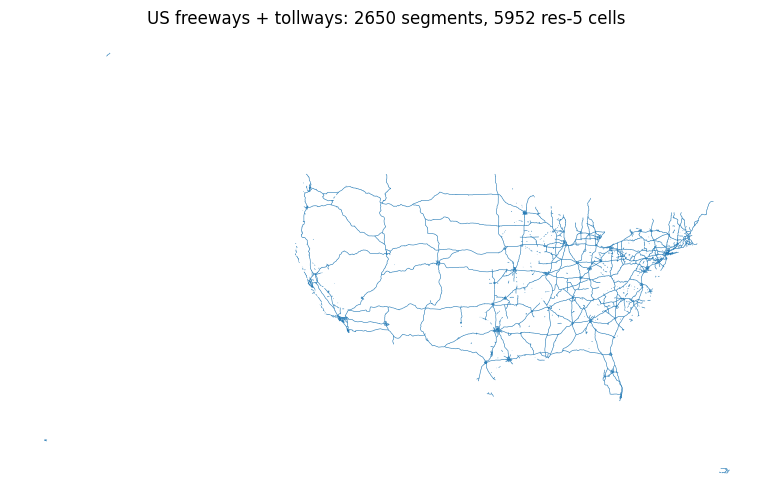

In [7]:
# eyeball the network
ax = gpd.GeoSeries(gdf.geometry, crs=4326).plot(linewidth=0.4, figsize=(11, 6))
ax.set_title(f"US freeways + tollways: {len(gdf)} segments, {len(cells)} res-{RES} cells")
ax.set_axis_off()